# PartUV × Texel Density —— 五步演示

把一个带贴图的模型交给 **PartUV**（part-aware UV 展开），再按**纹理内容的细节程度**
重新分配每个 chart 的纹素密度（单一参数 β，总预算不变），rebake 后导出最终资产
（GLB + atlas）。全流程通过统一入口
`map_partuv_td(input_mesh, output_dir, atlas_size, beta)` 完成，
导出前做几何完整性校验（原始尺度恢复 / 全部输入面保留 / 仅 seam 拆点 /
法线与材质参数保留），校验失败会明确报错而不是输出损坏资产。

**运行方式**：`geomae` kernel，Run All（约 1–2 分钟；启动时自动选一张空闲 GPU
做 PartField 推理 + 光栅化/rebake/预览渲染，无 GPU 时回退纯 CPU，约 3–5 分钟）。
打开时已嵌入全部输出。

| STEP | 内容 |
|---|---|
| 1 | 加载输入模型（几何 + 原贴图） |
| 2 | 统一入口运行：PartUV 分解与 UV 展开 |
| 3 | 对比度启发式分数（哪里需要更多纹素） |
| 4 | TD-aware 重排（β，Uniform 与 TD-aware 使用相同 atlas 尺寸） |
| 5 | Rebake → 对比 → 最终资产与完整性报告 |

In [1]:
# ============ 参数 ============
INPUT_MESH = "../data/objaverse_22b822c6520d4d49.glb"   # 换资产改这里
OUT_DIR    = "outputs/demo"
ATLAS_SIZE = "auto"   # "auto"(默认,预算平价: 1.00-1.05x 匹配输入预算) 或整数如 1024(固定存储预算,严格尊重)
MAX_ATLAS  = 8192
BETA       = 0.75      # 密度重分配强度(项目验证选定的默认值; 0=不重分配)

import os, sys
sys.path.insert(0, os.path.abspath(".."))          # tdlib
sys.path.insert(0, os.path.abspath("../scripts"))  # 渲染辅助

from tdlib import gpu as tdgpu
tdgpu.pick_free_gpu()   # 须在 CUDA 初始化前: 自动选空闲 GPU(设 CUDA_VISIBLE_DEVICES 可覆盖)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection

from tdlib.api import map_partuv_td                # 唯一管线入口
from tdlib.rd import bilinear                      # 仅用于展示取色
from gen_dashboard_assets import render_img, facing_view
%matplotlib inline

from contextlib import contextmanager, redirect_stdout, redirect_stderr

@contextmanager
def quiet():
    """折叠 PartUV/PartField 日志(含 C++ 核心直写 fd 的部分)."""
    from io import StringIO
    dn = os.open(os.devnull, os.O_WRONLY)
    s1, s2 = os.dup(1), os.dup(2)
    os.dup2(dn, 1); os.dup2(dn, 2)
    try:
        with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
            yield
    finally:
        os.dup2(s1, 1); os.dup2(s2, 2)
        for fd in (s1, s2, dn):
            os.close(fd)

def show(*imgs, titles=None, figw=15):
    fig, axs = plt.subplots(1, len(imgs), figsize=(figw, figw / len(imgs) * 1.08))
    for ax, im, t in zip(np.atleast_1d(axs), imgs, titles or [""] * len(imgs)):
        ax.imshow(im); ax.set_axis_off(); ax.set_title(t, fontsize=10)
    plt.tight_layout(); plt.show()

def uv_plot(ax, uvs, chart_colors, title):
    for c, uv, col in zip(charts, uvs, chart_colors):
        ax.add_collection(PolyCollection(uv[np.asarray(c["F"])],
                                         facecolors=col, edgecolors="none"))
    ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_axis_off(); ax.set_title(title, fontsize=10)

def hi_res_render(tex, uv_faces, ok, view, levels=3):
    """近似预览(STEP 1/5 共用, 依赖全局 V, F——STEP 1 赋值):
    有 GPU 时逐像素纹理采样(精确且快); CPU 回退用中点细分——
    每面 1 色会把高频纹理采样成走样伪影, 故细分后再采样."""
    if tdgpu.available():
        return tdgpu.textured_render(V, F, uv_faces, ok, tex, view=view)
    t3, t2, mk = V[F], uv_faces.copy(), ok.copy()
    for _ in range(levels):                    # 中点细分: 每面 -> 4 子面
        m3 = (t3 + np.roll(t3, -1, axis=1)) / 2
        m2 = (t2 + np.roll(t2, -1, axis=1)) / 2
        t3 = np.concatenate([np.stack([t3[:, 0], m3[:, 0], m3[:, 2]], 1),
                             np.stack([m3[:, 0], t3[:, 1], m3[:, 1]], 1),
                             np.stack([m3[:, 2], m3[:, 1], t3[:, 2]], 1), m3])
        t2 = np.concatenate([np.stack([t2[:, 0], m2[:, 0], m2[:, 2]], 1),
                             np.stack([m2[:, 0], t2[:, 1], m2[:, 1]], 1),
                             np.stack([m2[:, 2], m2[:, 1], t2[:, 2]], 1), m2])
        mk = np.concatenate([mk, mk, mk, mk])
    col = np.full((len(t3), 3), 0.6)
    col[mk] = bilinear(tex, t2[mk].mean(axis=1))
    Vs = t3.reshape(-1, 3)
    return render_img(Vs, np.arange(len(Vs)).reshape(-1, 3), col, view=view)

[tdlib.gpu] 使用空闲 GPU 1 (CUDA_VISIBLE_DEVICES=1)


## STEP 1 · 统一入口运行 + 输入模型

一次调用 `map_partuv_td` 完成整条管线（读取与边界检查 → PartUV → 内容分数 →
β 重分配 → packing → rebake → 完整性校验 → 导出）；本步与后续 STEP 全部展示
返回值 `res` 里的产物，**不假设输入只有单个 baseColorTexture**（多材质/异常资产
由入口给出明确结论，不会在调用前崩溃）。

输入边界：普通 UV overlap/trim-sheet 给出 **WARNING** 并在 rebake 时**唯一化**
（共享内容复制为各 chart 独立纹素）；tiled/UDIM 报 **`UNSUPPORTED`**。

左图模型预览与 STEP 5 同一近似渲染（GPU 逐像素纹理采样 / 无 GPU 时每面 64×
细分后采样），避免逐面平涂把高频贴图渲染成走样伪影。

输入: objaverse_22b822c6520d4d49.glb | 9,523 顶点 / 14,458 面 / 原贴图 1024x1024


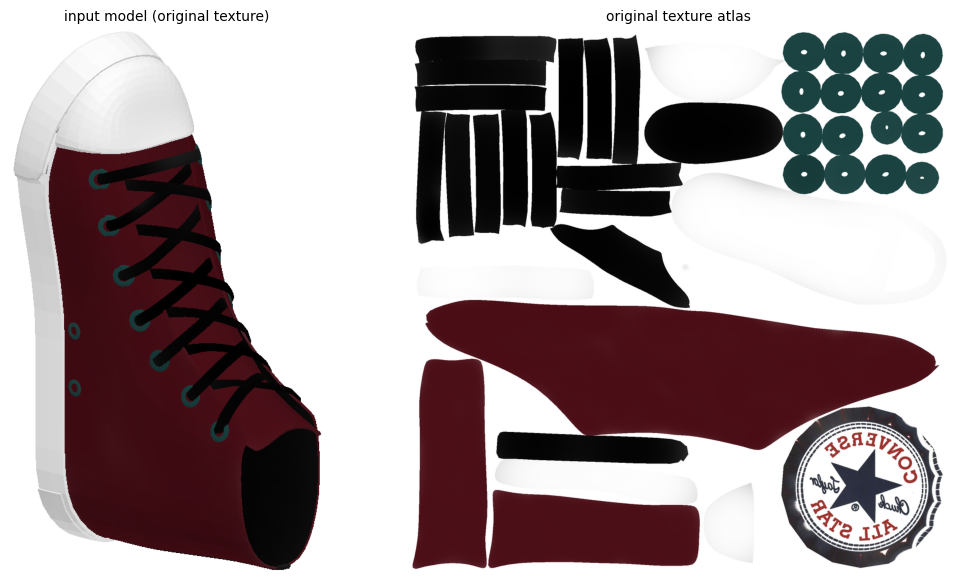

In [2]:
with quiet():                              # 折叠 PartUV/PartField 日志
    res = map_partuv_td(INPUT_MESH, OUT_DIR, atlas_size=ATLAS_SIZE, beta=BETA,
                        max_atlas=MAX_ATLAS)

pu, charts = res["pu"], res["pu"]["charts"]
V, F, area, covered = pu["V"], pu["F"], pu["area"], pu["covered"]
texA, face_refuv, valid = res["texA"], res["face_refuv"], res["valid"]
ii = res["integrity"]
print(f"输入: {os.path.basename(INPUT_MESH)} | {ii['n_vertices_in']:,} 顶点 / "
      f"{ii['n_faces_in']:,} 面 / 原贴图 {texA.shape[1]}x{texA.shape[0]}")
show(hi_res_render(texA, face_refuv, valid, (15, 45)), texA,
     titles=["input model (original texture)", "original texture atlas"], figw=11)

### 绝对纹素预算

在源贴图**原生分辨率**下按 UV island mask 实测输入的 surface texel budget，
auto 模式据此做**预算平价**：搜索最小方形分辨率（16 步长，非 POT）使 packing
后实测 B_signal/B_target ∈ [1.00, 1.05]；packer=xatlas（利用率一等目标）。

In [3]:
b = res["budget"]
mode = "自动(预算平价)" if ATLAS_SIZE == "auto" else f"用户固定({ATLAS_SIZE})"
in_band = 1.00 <= b["budget_ratio"] <= 1.05
print(f"B_target:     {b['B_target'] / 1e6:.2f}M texels (源表面采样预算 B_surface; "
      f"复用倍率 {b['source_reuse_factor']:.2f}x)")
print(f"B_signal:     {b['output_B_signal'] / 1e6:.2f}M texels "
      f"({mode}输出 {b['selected_atlas_size']}^2, packer={b['packer']})")
print(f"budget ratio: {b['budget_ratio']:.3f}x"
      + ("  — 已匹配输入预算(1.00–1.05x)" if in_band else ""))
print(f"packing fill: {b['output_packing_fill'] * 100:.0f}%")
print(f"E_alloc:      {b['E_alloc'] * 100:.2f}%  (TD 分配分布误差, 合同 <= 1%)")
if not b["budget_met"]:
    print("WARNING — 用户固定存储预算低于输入参考, 可能外观降级")

B_target:     0.66M texels (源表面采样预算 B_surface; 复用倍率 1.00x)
B_signal:     0.69M texels (自动(预算平价)输出 1152^2, packer=xatlas)
budget ratio: 1.049x  — 已匹配输入预算(1.00–1.05x)
packing fill: 52%
E_alloc:      0.29%  (TD 分配分布误差, 合同 <= 1%)


## STEP 2 · PartUV 分解与 UV 展开

PartUV 按语义部件把模型切成 charts 并展开。基线布局 = chart UV 面积 ∝ 3D 面积
（均匀纹素密度），是 STEP 4 重排的对照组。

PartUV: 223 charts, 覆盖 99.96% 面(未覆盖面保留见 STEP 5 完整性报告)


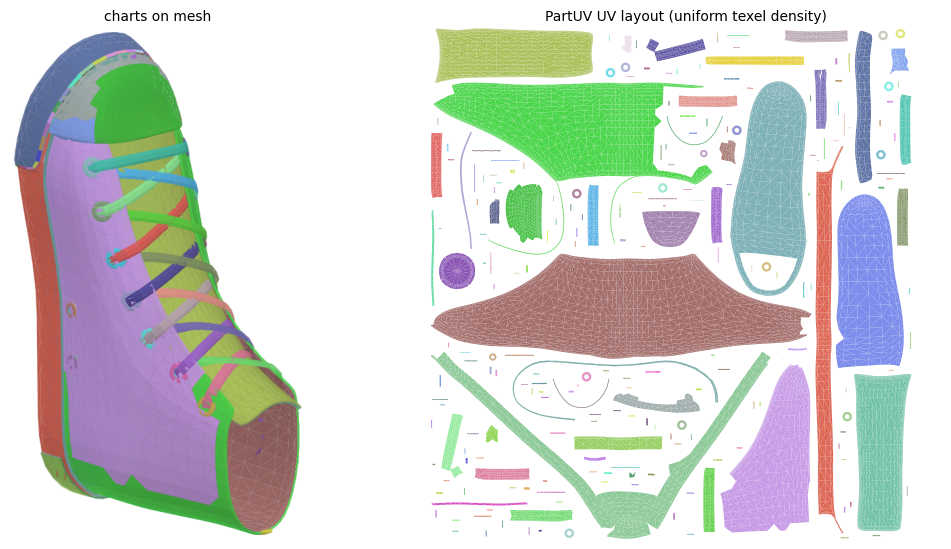

In [4]:
print(f"PartUV: {len(charts)} charts, 覆盖 {covered.mean() * 100:.2f}% 面"
      f"(未覆盖面保留见 STEP 5 完整性报告)")

rng = np.random.default_rng(0)
ccol = rng.uniform(0.25, 0.95, (len(charts), 3))
col_chart = np.full((len(F), 3), 0.7)
for ci, c in enumerate(charts):
    col_chart[c["gidx"]] = ccol[ci]
fig, axs = plt.subplots(1, 2, figsize=(11.5, 5.6))
axs[0].imshow(render_img(V, F, col_chart)); axs[0].set_axis_off()
axs[0].set_title("charts on mesh", fontsize=10)
uv_plot(axs[1], res["uvs_uniform"], ccol, "PartUV UV layout (uniform texel density)")
plt.tight_layout(); plt.show()

## STEP 3 · 对比度启发式分数（哪里需要更多纹素）

在原贴图上测每个面的亮度变化（luminance-std）：亮 = 对比度高，暗 = 平坦。
这是**对比度启发式**（不是空间频率度量），作为密度需求信号。

**计算公式**（`tdlib.signal.luminance_std_heuristic`，逐面）：

$$cw(f) \;=\; \mathrm{std}\big(\,Y(t_1),\,\dots,\,Y(t_{24})\,\big),
\qquad Y = 0.299R + 0.587G + 0.114B$$

- $t_1..t_{24}$：面 $f$ 内固定的 24 个重心坐标采样点（Dirichlet(1.2)，seed 固定、
  全部面共用同一组），映射到该面在**原贴图**上的 UV 处取色（nearest）；
- 未能匹配到原贴图的面 $cw=0$；
- 命名为 *heuristic*：它度量的是**对比幅值**，不度量空间频率；
- 下方热力图仅为可视化：对 $\log \max(cw,\, 1/510)$ 按 [P5, P99] 分位归一后
  着色——低于半个 8-bit 量化步的亮度变化不可感知，一律视为平坦（最暗色），
  防止纯色区 $cw=0$/浮点碎屑把 log 窗口拉爆成椒盐图；右图视角按 z-buffer
  实测可见性选取（正对最高对比 chart 的可见侧，遮挡已考虑）。
  $cw$ 如何变成 chart 面积倍率见 STEP 4（β 映射 + 预算归一）。

最高对比度 chart: #207 (面积加权 luminance-std 最高的 >=100 面 chart)


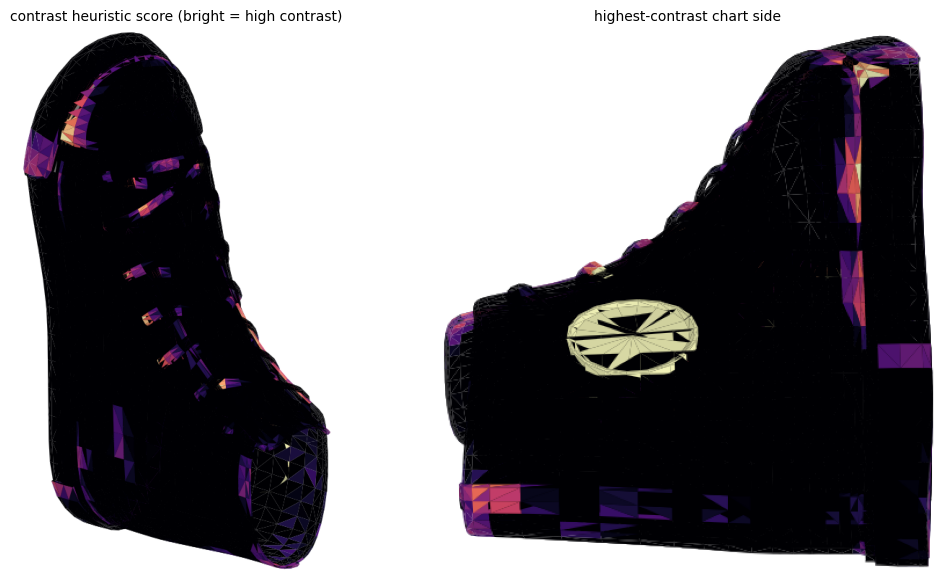

In [5]:
cw, sel = res["cw"], res["sel"]
kk = res["top_chart"]
z = np.log(np.maximum(cw, 1 / 510))   # 显示地板: 半个 8-bit 量化步, 亚量化变化视为平坦
lo, hi = np.quantile(z[sel], [0.05, 0.99])
heat = plt.cm.magma(np.clip((z - lo) / max(hi - lo, 1e-9), 0, 1))[:, :3]
heat[~sel] = 0.5
view_top = facing_view(V, F, charts[kk]["gidx"],
                       w=np.asarray(cw)[charts[kk]["gidx"]])  # 相机朝向高对比一侧
print(f"最高对比度 chart: #{kk} (面积加权 luminance-std 最高的 >=100 面 chart)")
show(render_img(V, F, heat), render_img(V, F, heat, view=view_top),
     titles=["contrast heuristic score (bright = high contrast)",
             "highest-contrast chart side"], figw=11)

## STEP 4 · TD-aware 重排（β，相同 atlas 尺寸）

对比度分数 → 单一参数 β 控制强度 → 预算归一化（**打包前连续需求总量不变**；离散化后的实际分配见预算区块 E_alloc）→ chart 按需缩放后重新
打包。两张布局用同一套内容分数着色——**颜色相同、面积不同**：细节 chart（亮色）
变大，平坦 chart（暗色）让出预算。

**计算公式**（`tdlib.signal.demand_weights` 逐面 → `tdlib.layout.layout_with_scales` 逐 chart）：

$$z(f) = \frac{\log cw(f) - \mathrm{med}_A}{\mathrm{MAD}_A},
\qquad q(f) = \exp\big(\beta \cdot \mathrm{clip}(z,\, \pm 2.5)\big),
\qquad w(f) = q(f)^2$$

- $\mathrm{med}_A/\mathrm{MAD}_A$：**面积加权**的 log 域中位数/中位绝对偏差（稳健 z-score，
  防止少数极端面主导）；
- **预算归一化**（迭代 3 次）：$q \leftarrow q / \sqrt{\mathrm{mean}_A(q^2)}$ 后裁剪到
  $[0.5,\, 2.83]$ ⇒ 数值上 $\mathrm{mean}_A(w) = 1$，**打包前连续需求总量不变**（打包后离散分配见 E_alloc）；$\beta=0$ 时严格
  $q \equiv 1$（退化为均匀基线）；
- 语义：$q$ = 线性纹理密度倍率（$TD_{new} = q \cdot TD_{uniform}$），$w = q^2$ = 面积预算倍率；
- **chart 级落地**：每 chart 需求 $= \sum_f A_{3D}(f)\, w(f)$ → 线性缩放
  $f_c = \sqrt{\text{demand}/A_{UV}}$ → xatlas packing 重新打包（刚体旋转/平移 + 共享全局缩放）。

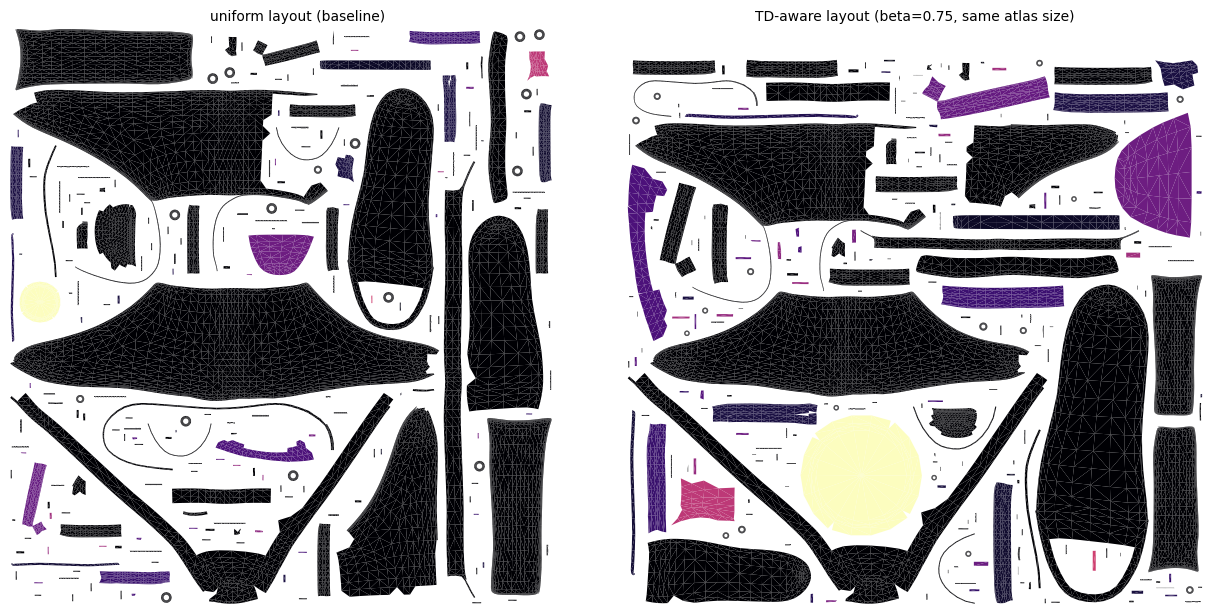

chart 面积倍率(vs 均匀): 最高细节 chart #207 ×8.8, 中位 ×0.81, 范围 [0.26, 8.78]


In [6]:
heat_c = plt.cm.magma(np.clip(
    (np.log(np.maximum(np.asarray(res["mean_cw"]), 1 / 510)) - lo)
    / max(hi - lo, 1e-9), 0, 1))[:, :3]
fig, axs = plt.subplots(1, 2, figsize=(12.5, 6.1))
uv_plot(axs[0], res["uvs_uniform"], heat_c, "uniform layout (baseline)")
uv_plot(axs[1], res["uvs_td"], heat_c,
        f"TD-aware layout (beta={BETA}, same atlas size)")
plt.tight_layout(); plt.show()

def _areas(uvs):
    return np.array([np.abs(np.cross(
        uv[np.asarray(c['F'])][:, 1] - uv[np.asarray(c['F'])][:, 0],
        uv[np.asarray(c['F'])][:, 2] - uv[np.asarray(c['F'])][:, 0])).sum() / 2
        for c, uv in zip(charts, uvs)])
r = _areas(res["uvs_td"]) / np.maximum(_areas(res["uvs_uniform"]), 1e-12)
print(f"chart 面积倍率(vs 均匀): 最高细节 chart #{kk} ×{r[kk]:.1f}, "
      f"中位 ×{np.median(r):.2f}, 范围 [{r.min():.2f}, {r.max():.2f}]")

## STEP 5 · Rebake → 对比 → 最终资产

Uniform 与 TD-aware 使用**相同 atlas 尺寸**（各自实际有效纹素 B_signal 见输出）。TD-aware atlas 即最终资产所用贴图。

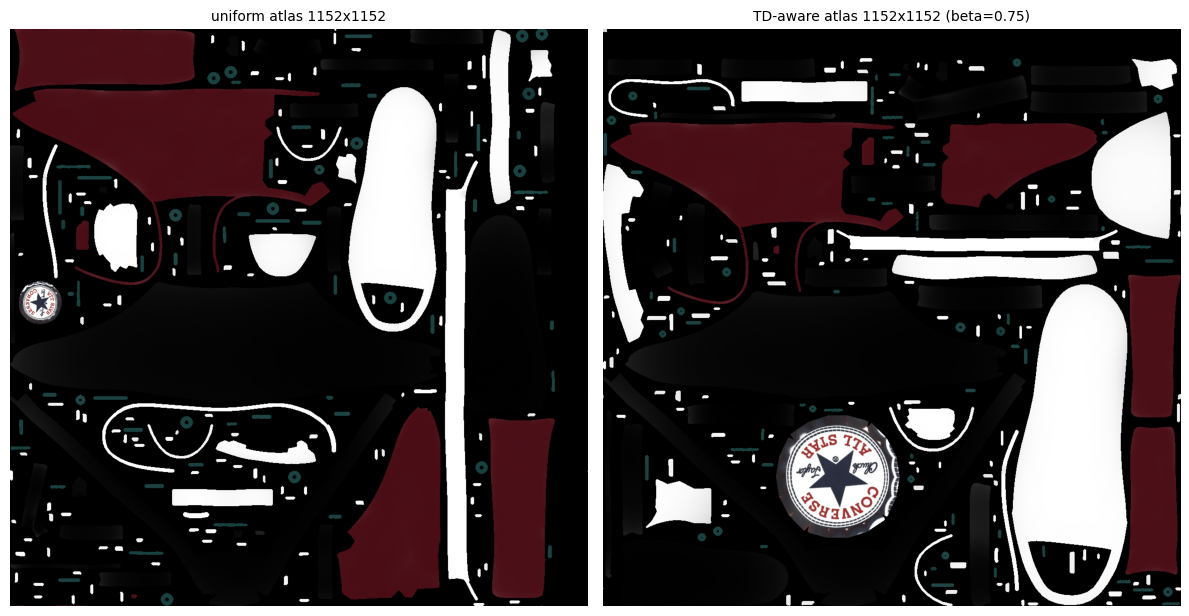

实际有效纹素: uniform B_signal=0.62M, TD-aware B_signal=0.69M (相同 atlas 尺寸, 非相同有效预算)


In [7]:
R = res["atlas_size"]
b = res["budget"]
show(res["tex_uniform"], res["tex_td"],
     titles=[f"uniform atlas {R}x{R}",
             f"TD-aware atlas {R}x{R} (beta={BETA})"], figw=12)
print(f"实际有效纹素: uniform B_signal={b['output_B_signal_uniform']/1e6:.2f}M, "
      f"TD-aware B_signal={b['output_B_signal']/1e6:.2f}M (相同 atlas 尺寸, 非相同有效预算)")

### 最高对比度 chart 局部对比

同一个 chart 在两张同尺寸 atlas 里的裁剪——TD-aware 给了它更多纹素。

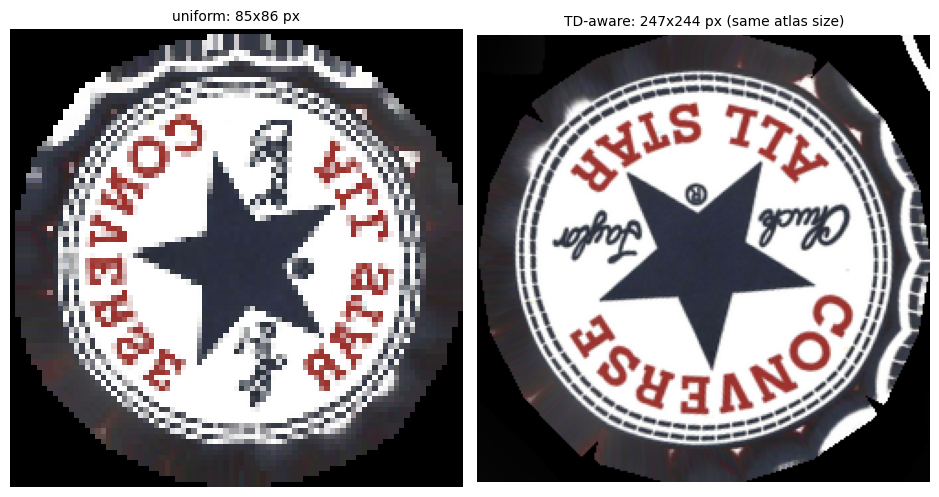

In [8]:
def crop_chart(tex, uv, R):
    mn = np.maximum((np.array([uv[:, 0].min(), 1 - uv[:, 1].max()]) * R).astype(int) - 2, 0)
    mx = np.minimum((np.array([uv[:, 0].max(), 1 - uv[:, 1].min()]) * R).astype(int) + 2, R)
    return tex[mn[1]:mx[1], mn[0]:mx[0]]

cb = crop_chart(res["tex_uniform"], res["uvs_uniform"][kk], res["atlas_size"])
ct = crop_chart(res["tex_td"], res["uvs_td"][kk], res["atlas_size"])
show(cb, ct, titles=[f"uniform: {cb.shape[1]}x{cb.shape[0]} px",
                     f"TD-aware: {ct.shape[1]}x{ct.shape[0]} px (same atlas size)"],
     figw=9.5)

### 同视角对比（近似预览）

左：原始贴图；中/右：两种 atlas 贴回模型。
**此三联图为近似预览**——有 GPU 时用逐像素纹理采样的正交软光栅渲染，
无 GPU 回退到每面 64× 细分的 matplotlib 近似；两者都不是导出 GLB 的
真实渲染（导出资产请在 DCC/引擎中查看）。视角正对最高细节 chart。

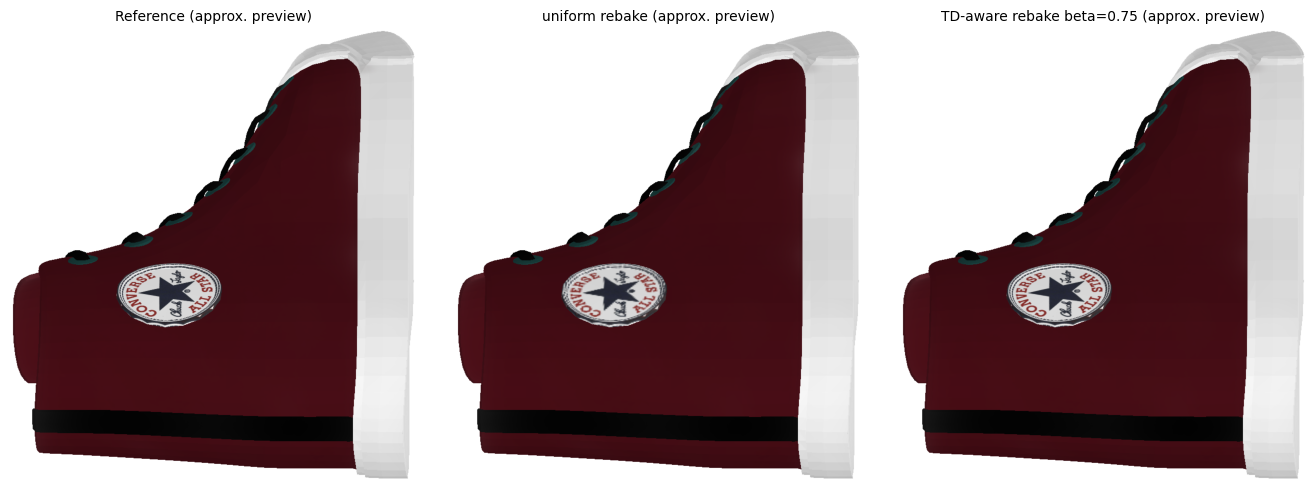

In [9]:
face_refuv, valid = res["face_refuv"], res["valid"]
newuv_b = np.zeros((len(F), 3, 2)); newuv_t = np.zeros((len(F), 3, 2))
inchart = np.zeros(len(F), bool)
for ci, c in enumerate(charts):
    cF = np.asarray(c["F"]); g = c["gidx"]
    newuv_b[g] = res["uvs_uniform"][ci][cF]
    newuv_t[g] = res["uvs_td"][ci][cF]
    inchart[g] = True
show(hi_res_render(res["texA"], face_refuv, valid, view_top),
     hi_res_render(res["tex_uniform"], newuv_b, inchart, view_top),
     hi_res_render(res["tex_td"], newuv_t, inchart, view_top),
     titles=["Reference (approx. preview)", "uniform rebake (approx. preview)",
             f"TD-aware rebake beta={BETA} (approx. preview)"], figw=13.5)

### 最终资产与完整性报告

导出已由统一入口完成（校验失败会抛错、不产出文件）。输出名按输入文件自动生成。

In [10]:
ii = res["integrity"]
print(f"最终资产: {res['glb_path']} ({os.path.getsize(res['glb_path']) / 1e6:.1f} MB)")
print(f"          {res['atlas_path']} ({res['atlas_size']}x{res['atlas_size']})")
print()
print("完整性报告(输出坐标已恢复原始尺度/transform):")
print(f"  面数:   输入 {ii['n_faces_in']:,} -> 输出 {ii['n_faces_out']:,} (全部几何面保留)")
print(f"  顶点数: 输入 {ii['n_vertices_in']:,} -> 输出 {ii['n_vertices_out']:,}"
      f", 净增 {ii['n_vertices_net_increase']:,} (仅 UV seam 拆点, 非逐三角拆点;"
      f" 相对位置焊接基数 {ii['n_welded_positions']:,} 的 seam corner 增量为"
      f" {ii['n_extra_vs_welded_positions']:,})")
print(f"  表面积比 {ii['area_ratio']:.6f} | 包围盒偏差 {ii['bbox_dev']:.2e}"
      f" | 回读校验 {'PASS' if ii.get('reload_ok') else 'FAIL'}")
for wmsg in res["warnings"]:
    print(f"  [报告] {wmsg}")

最终资产: outputs/demo/objaverse_22b822c6520d4d49_td_aware.glb (0.8 MB)
          outputs/demo/objaverse_22b822c6520d4d49_td_aware_atlas.png (1152x1152)

完整性报告(输出坐标已恢复原始尺度/transform):
  面数:   输入 14,458 -> 输出 14,458 (全部几何面保留)
  顶点数: 输入 9,523 -> 输出 9,849, 净增 326 (仅 UV seam 拆点, 非逐三角拆点; 相对位置焊接基数 7,759 的 seam corner 增量为 2,090)
  表面积比 1.000000 | 包围盒偏差 1.14e-16 | 回读校验 PASS
  [报告] 全部几何面保留; 未覆盖的 0.015% 面(共 6 个)使用近似均色纹素, 外观可能轻微降级; 面号示例 [1, 2, 4, 6, 7]


## 固定存储预算质量对比（实验章节）

**问题**：相同 base-color raw texel 存储（$B_{raw}=\sum W_kH_k$）下，
PartUV-TD 是否比"原 UV 直接降采样"与 PartUV-Uniform 都更接近原生 Reference？
两档预算：50%（R=724）与 25%（R=512）。四组方法同 renderer/视角/滤波/线性色域；
降采样与 rebake 均用线性域 area 低通（rebake 为 4× 超采样等价抗锯齿）。
高频区 = Reference 自身梯度 top-10% 采样点（与分配信号无关）。
结果由 `scripts/run_storage_ab.py` 生成（只读加载，不在此重跑）。

—— 50pct (B_raw=524,176 = 49.99% of source) ——
  SourceUV-Downsample    PSNR=44.72dB  SSIM(8视角)=0.9997  高频MSE=3.36e-04
  PartUV-Uniform         PSNR=29.64dB  SSIM(8视角)=0.9795  高频MSE=5.41e-03
  PartUV-TD              PSNR=30.75dB  SSIM(8视角)=0.9838  高频MSE=1.74e-03
—— 25pct (B_raw=262,144 = 25.0% of source) ——
  SourceUV-Downsample    PSNR=40.94dB  SSIM(8视角)=0.9993  高频MSE=8.04e-04
  PartUV-Uniform         PSNR=27.82dB  SSIM(8视角)=0.975  高频MSE=7.77e-03
  PartUV-TD              PSNR=28.3dB  SSIM(8视角)=0.977  高频MSE=2.70e-03

鞋(源布局良好, 复用 1.0x)上的诚实结论:
  1) SourceUV-Downsample 显著更接近 Reference —— 重展开+重烘焙链路有
     固有地板(全预算 rebake MSE≈5.7e-4, 其中 ~64% 集中在 chart 边界带),
     且同 B_raw 下 xatlas 布局的有效纹素交付(48%)低于源布局(63%);
  2) PartUV-TD 一致优于 PartUV-Uniform(高频 MSE -68%/-65%) —— TD 分配
     本身的贡献为正, 与压缩基线的差距来自重展开链路而非 TD;
  3) 该协议适用于「已有良好 UV 的资产」; 无源 UV 可用的生成管线场景
     (本课题的 teacher/data 目标场景)中, 对照基线应为 PartUV-Uniform。


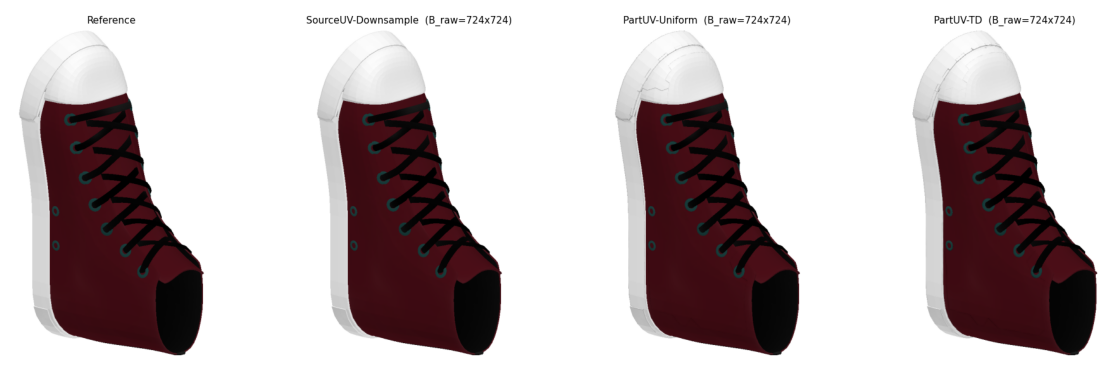

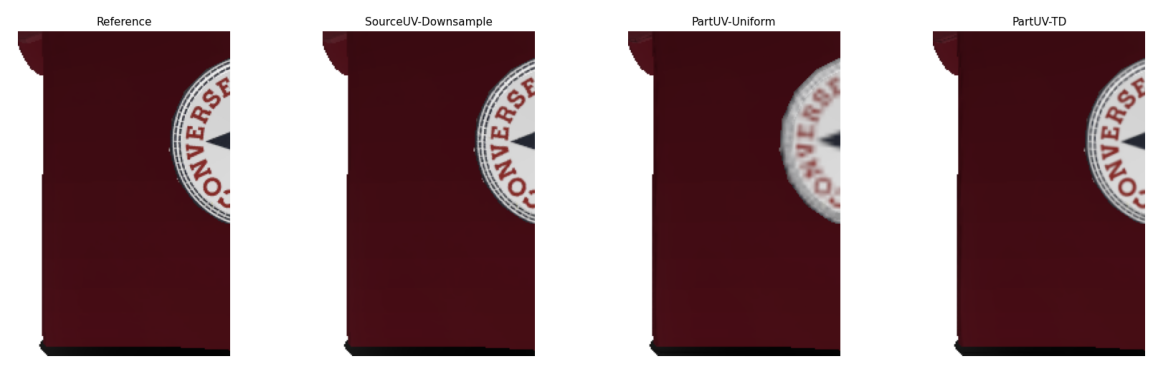

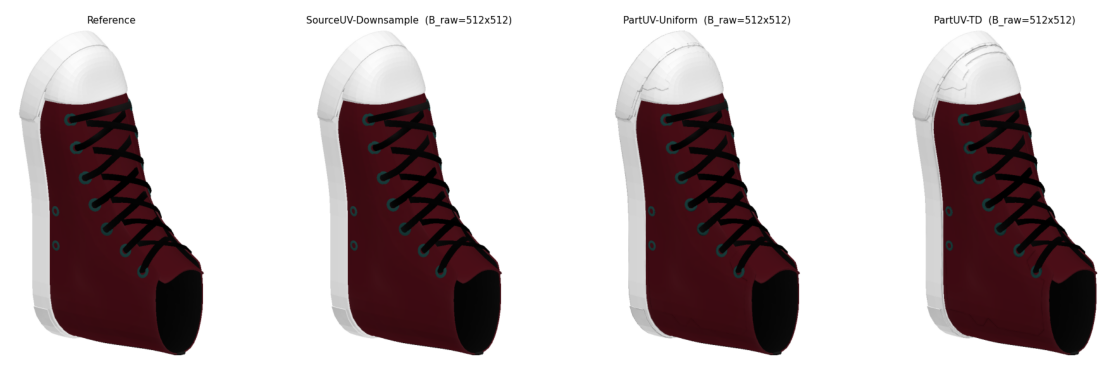

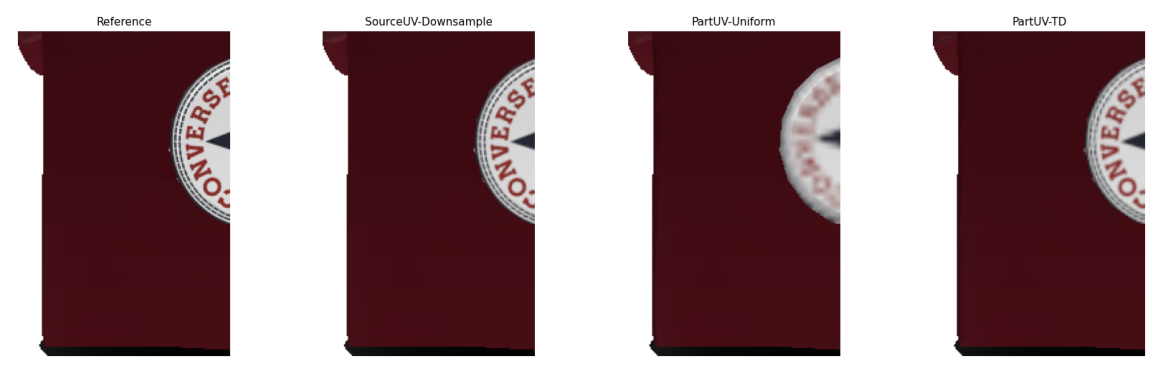

In [11]:
import json as _json
_ab = f"outputs/storage_ab/shoe"
try:
    _s = _json.load(open(f"{_ab}/summary.json"))
    for _t, _r in _s["tiers"].items():
        print(f"—— {_t} (B_raw={_r['B_raw']:,} = {_r['B_raw_pct_of_source']}% of source) ——")
        for _m, _v in _r["methods"].items():
            print(f"  {_m:22s} PSNR={_v['psnr_db']}dB  SSIM(8视角)={_v['ssim_8view_mean']}"
                  f"  高频MSE={_v['mse_hifreq_linear']:.2e}")
    print()
    print("鞋(源布局良好, 复用 1.0x)上的诚实结论:")
    print("  1) SourceUV-Downsample 显著更接近 Reference —— 重展开+重烘焙链路有")
    print("     固有地板(全预算 rebake MSE≈5.7e-4, 其中 ~64% 集中在 chart 边界带),")
    print("     且同 B_raw 下 xatlas 布局的有效纹素交付(48%)低于源布局(63%);")
    print("  2) PartUV-TD 一致优于 PartUV-Uniform(高频 MSE -68%/-65%) —— TD 分配")
    print("     本身的贡献为正, 与压缩基线的差距来自重展开链路而非 TD;")
    print("  3) 该协议适用于「已有良好 UV 的资产」; 无源 UV 可用的生成管线场景")
    print("     (本课题的 teacher/data 目标场景)中, 对照基线应为 PartUV-Uniform。")
    from matplotlib.image import imread as _imread
    for _t in _s["tiers"]:
        for _fig in ("quad_main", "crop_logo"):
            _p = f"{_ab}/{_t}_{_fig}.png"
            if os.path.exists(_p):
                plt.figure(figsize=(16, 4.6)); plt.imshow(_imread(_p))
                plt.axis("off"); plt.show()
except FileNotFoundError as _e:
    print(f"[缺失] {_e} —— 先运行 scripts/run_storage_ab.py")

## 结论

- **得到什么**：`<输入名>_td_aware.glb` + `<输入名>_td_aware_atlas.png`——
  相同 atlas 尺寸下把纹素向高对比度区域倾斜、几何与原模型逐面一致的最终资产。
  （“同等存储下比直接降采样更接近原贴图”是**待验证假设**——见下方
  “固定存储预算质量对比”章节；鞋上的首轮结果为否定，TD 相对 Uniform 的
  改善为肯定。）
- **方法**：PartUV charts → 对比度启发式分数 → 单一参数 β → 预算归一化 →
  chart 缩放 + packing → rebake，经 `map_partuv_td` 一次调用完成。
- **边界**：普通 UV overlap/trim-sheet = WARNING + 唯一化 rebake；
  tiled/UDIM = `UNSUPPORTED`；仅重烘 base-color 单 atlas。